## Principles of Machine Learning Final Project
**By: Saheli Ray, Wyatt Golden, HuiDi Hu, Ayam Agarwal**

This notebook builds a complete tabular machine-learning workflow for predicting whether a wildlife strike caused aircraft damage. The project moves from exploratory analysis, to targeted cleaning and feature engineering, to several class-imbalance-aware models, and finally to a compact validation comparison. Throughout the project, we prioritized features and models that generalize across airports, operators, aircraft, and wildlife categories instead of memorizing sparse identifiers.


In [1]:
# All imports needed for the project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

import warnings
warnings.filterwarnings("ignore")

pd.options.display.max_columns = 100
        


In [2]:
# Quick environment check
%cd /home/jovyan/work
!ls

/home/jovyan/work
boosted_tree_submission.csv		     lightgbm_submission.csv
decision_tree_submission.csv		     ml_plan.md
extra_trees_submission.csv		     neural_net_submission.csv
FinalProject.ipynb			     random_forest_submission.csv
hist_gradient_boosting_submission.csv	     README.md
hist_gradient_boosting_tuned_submission.csv  sample_submission.csv
HuiDi_Model_Training.ipynb		     test.csv
HuiDis_Data_Exploration.ipynb		     train.csv


## Data Exploration

This project predicts whether a wildlife strike caused aircraft damage. The exploration section is intentionally kept in one place so the reader can see the whole data story before the notebook moves into cleaning and modeling: the target is highly imbalanced, many raw fields are sparse or identifier-like, and several domain variables such as flight phase, animal size, speed, height, and month show useful relationships with damage.

The main modeling goal is not simply to maximize plain accuracy. Because most strikes do not report damage, a model can look accurate while ignoring the damage class. For that reason, the rest of the notebook emphasizes balanced accuracy, recall, and class-aware modeling decisions.


In [2]:
# Load dataset and look at its shape and first 5 rows
train = pd.read_csv("train.csv", low_memory=False)
print("Dataset shape:", train.shape)
train.head(5)

Dataset shape: (307178, 55)


,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,LATITUDE,LONGITUDE,RUNWAY,STATE,FAAREGION,LOCATION,OPID,OPERATOR,REG,FLT,AIRCRAFT,AMA,AMO,EMA,EMO,AC_CLASS,AC_MASS,TYPE_ENG,NUM_ENGS,ENG_1_POS,ENG_2_POS,ENG_3_POS,ENG_4_POS,PHASE_OF_FLIGHT,HEIGHT,SPEED,DISTANCE,SKY,PRECIPITATION,BIRD_BAND_NUMBER,SPECIES_ID,SPECIES,OUT_OF_RANGE_SPECIES,REMARKS,REMAINS_COLLECTED,REMAINS_SENT,WARNED,NUM_SEEN,NUM_STRUCK,SIZE,ENROUTE_STATE,COMMENTS,SOURCE,PERSON,LUPDATE,TRANSFER,INDICATED_DAMAGE
0,1410120,12/13/93,12,1993,NaN,Day,TJSJ,LUIS MUNOZ MARIN INTL,18.43942,-66.00183,7,PR,ASO,NaN,AAL,AMERICAN AIRLINES,N892AA,NaN,B-727-200,148,11,34.0,10.0,A,4.0,D,3.0,5.0,6.0,5.0,NaN,Approach,300.0,145.0,NaN,Some Cloud,NaN,NaN,UNKBS,Unknown bird - small,0,NO SIGN OF BIRD ON A/C.,1,0,No,10-Feb,10-Feb,Small,NaN,NaN,FAA Form 5200-7,Pilot,4/3/23,0,0
1,709688,2/1/10,2,2010,5:00,Night,WMKK,KUALA LUMPUR INTL,2.745578,101.709917,32R,FN,FGN,NaN,FDX,FEDEX EXPRESS,N608FE,5293,MD-11,583,39,22.0,7.0,A,4.0,D,3.0,1.0,6.0,1.0,NaN,Approach,50.0,NaN,0.0,NaN,NaN,NaN,UNKBM,Unknown bird - medium,0,EVID OF STRIKE FOUND ON LOWER RT SIDE OF RADOME.,0,0,Unknown,NaN,1,Medium,NaN,2010-5-18-53374 /Legacy Record 300758/,FAA Form 5200-7-E,Air Transport Operations,6/9/10,0,0
2,730841,5/9/12,5,2012,2:00,Night,KSDF,MUHAMMAD ALI INTERNATIONAL,38.17439,-85.736,35L,KY,ASO,NaN,UPS,UPS AIRLINES,N141UP,907,A-300,04A,1,34.0,46.0,A,4.0,D,2.0,1.0,1.0,NaN,NaN,Approach,3500.0,240.0,8.0,NaN,NaN,NaN,UNKBL,Unknown bird - large,0,"STARTED TO SLOW DOWN FROM 250 KTS AT AROUND 4,...",0,0,No,NaN,1,Large,NaN,UPS EVENT REPT 36216 (4/22/13 UPDATED COST) /L...,Air Transport Report,Air Transport Operations,4/22/13,0,1
3,654676,10/8/02,10,2002,NaN,NaN,KLAX,LOS ANGELES INTL,33.94254,-118.40807,25R,CA,AWP,NaN,UNK,UNKNOWN,NaN,NaN,UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NE120,Western gull,0,REMAINS OF 2 GULLS WERE PICKED UP OF RWY.,1,0,Unknown,NaN,10-Feb,Medium,NaN,2002-10-8-111929 /Legacy Record 216397/,FAA Form 5200-7-E,Carcass Found,1/9/03,0,0
4,629708,2/3/97,2,1997,NaN,Dawn,PHLI,LIHUE ARPT,21.97598,-159.33896,35,HI,AWP,NaN,1AAH,ALOHA AIRLINES,NaN,NaN,B-737-200,148,13,34.0,10.0,A,4.0,D,2.0,1.0,1.0,NaN,NaN,Landing Roll,0.0,135.0,0.0,Some Cloud,NaN,NaN,R1101,American barn owl,0,TIME 0824 LCL.,0,0,No,1,1,Medium,NaN,SOURCE 5200-7 & PACIR /Legacy Record 121531/,Multiple,NaN,3/1/07,0,0


The first figure follows the organization from the HuiDis exploration notebook: class balance, monthly volume, bird-size damage rate, phase-of-flight damage rate, speed distribution, and the highest-missing columns. The remaining figures keep the more detailed FinalProject plots for candidate feature missingness, damage rates, month patterns, numeric distributions, and missingness-as-signal.


Training shape: (307178, 55)
Target damage rate: 0.0636


,count
INDICATED_DAMAGE,
0,287651
1,19527


Top columns by missing percentage


,missing_percent
BIRD_BAND_NUMBER,99.767887
ENG_4_POS,98.935796
ENROUTE_STATE,98.259641
PRECIPITATION,96.349999
ENG_3_POS,95.977577
LOCATION,87.232810
SPEED,69.040101
NUM_SEEN,67.890930
SKY,53.006726
FLT,52.554219


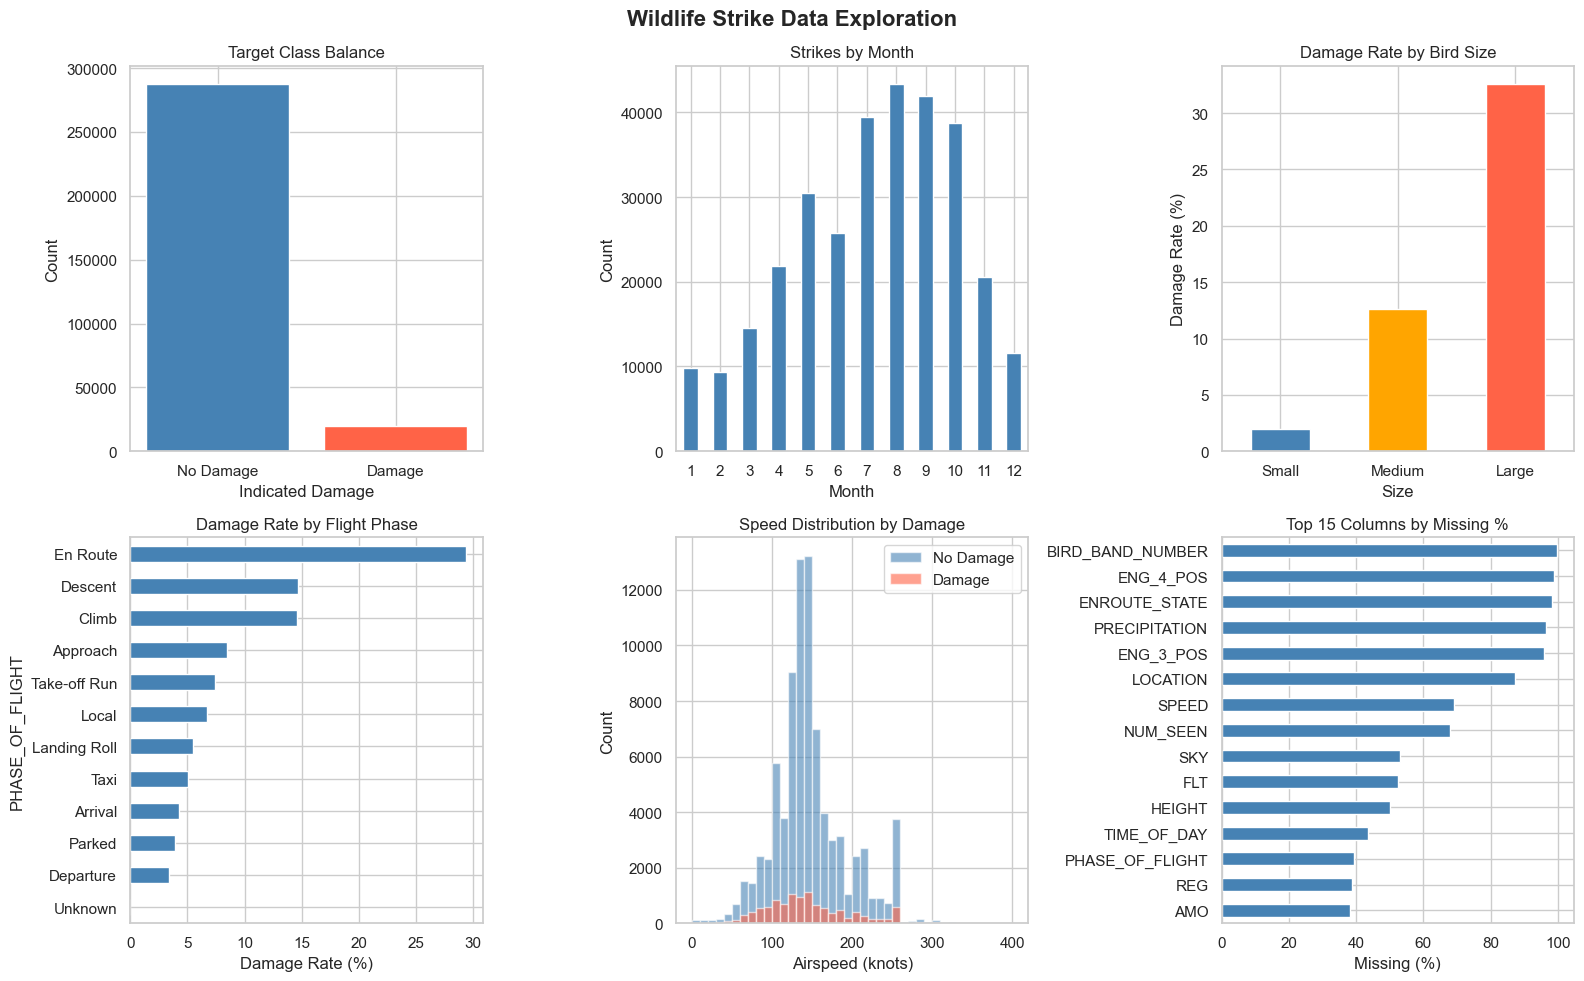

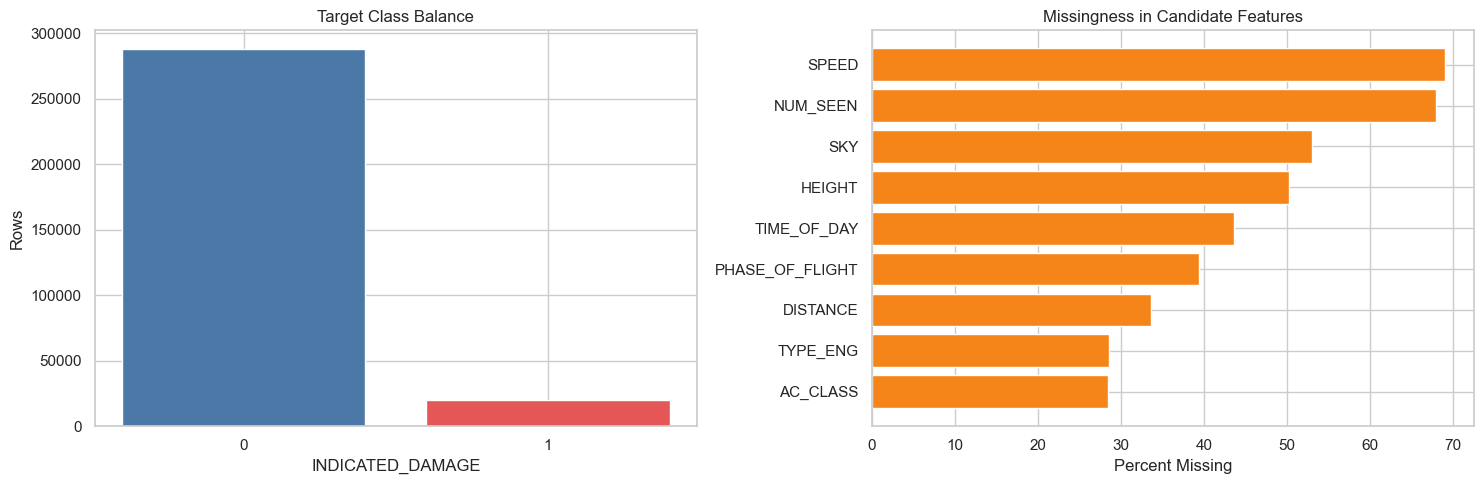

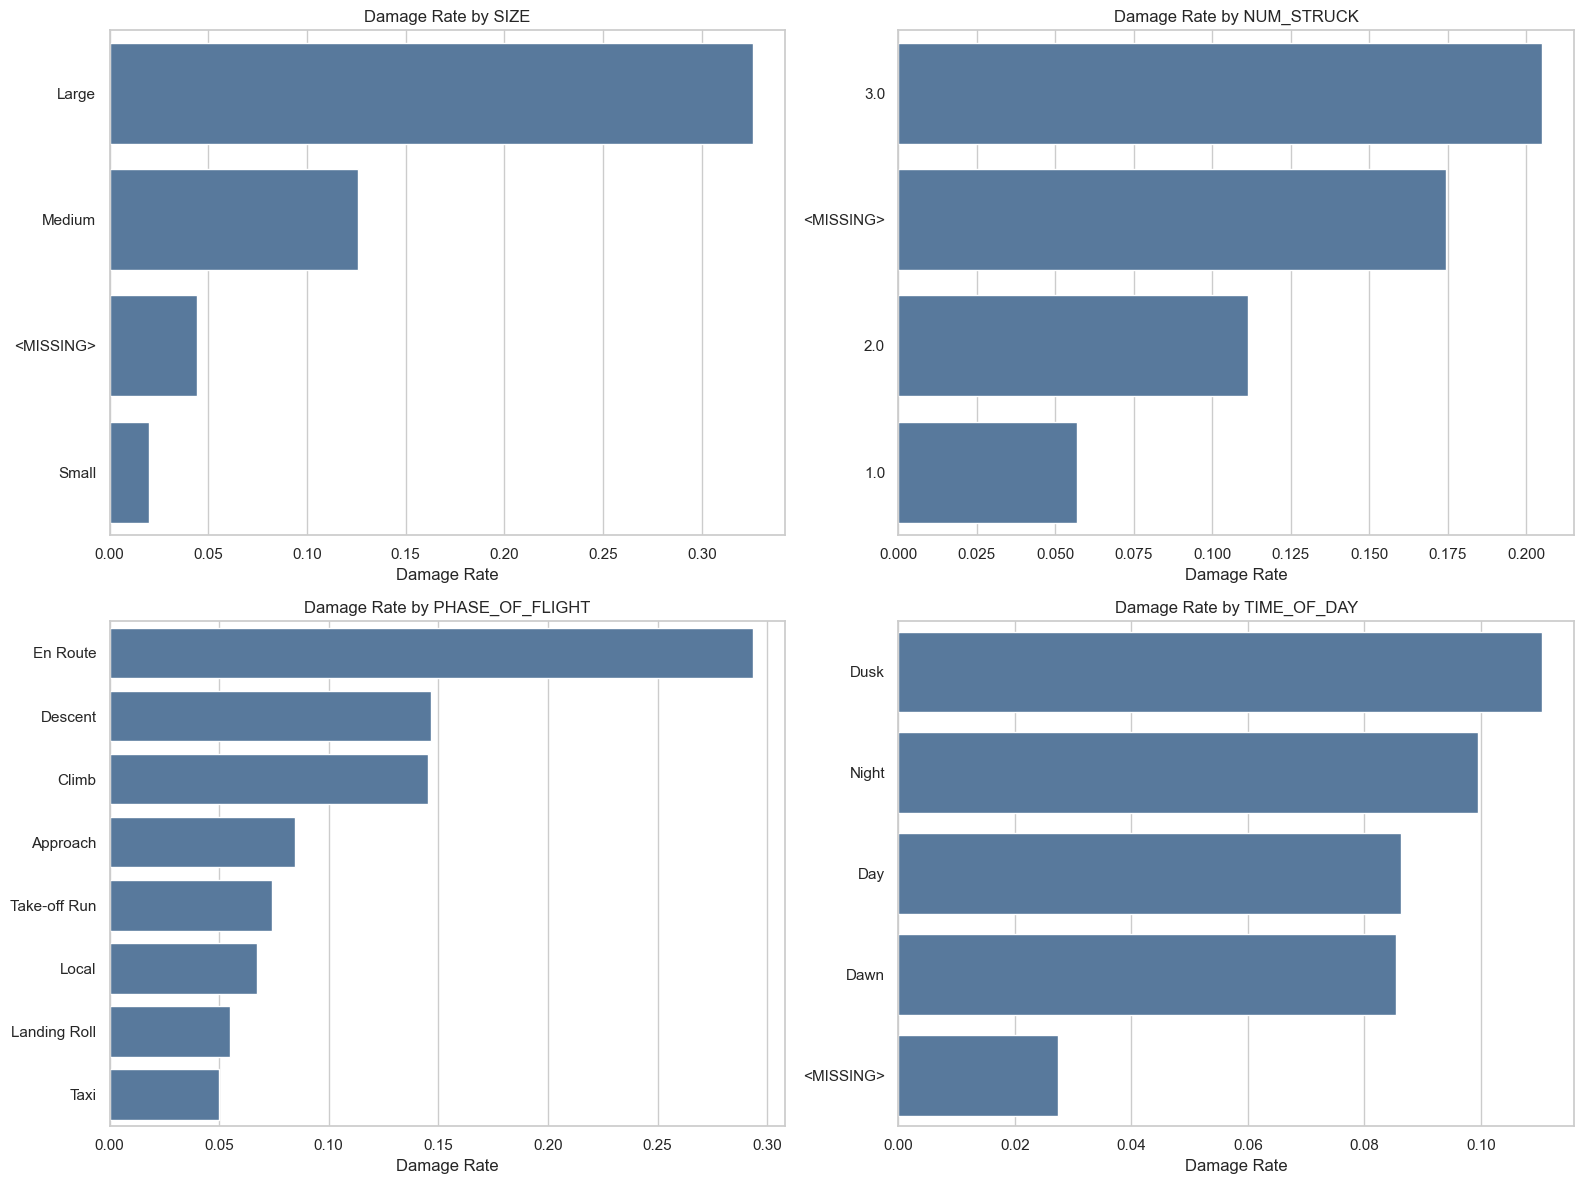

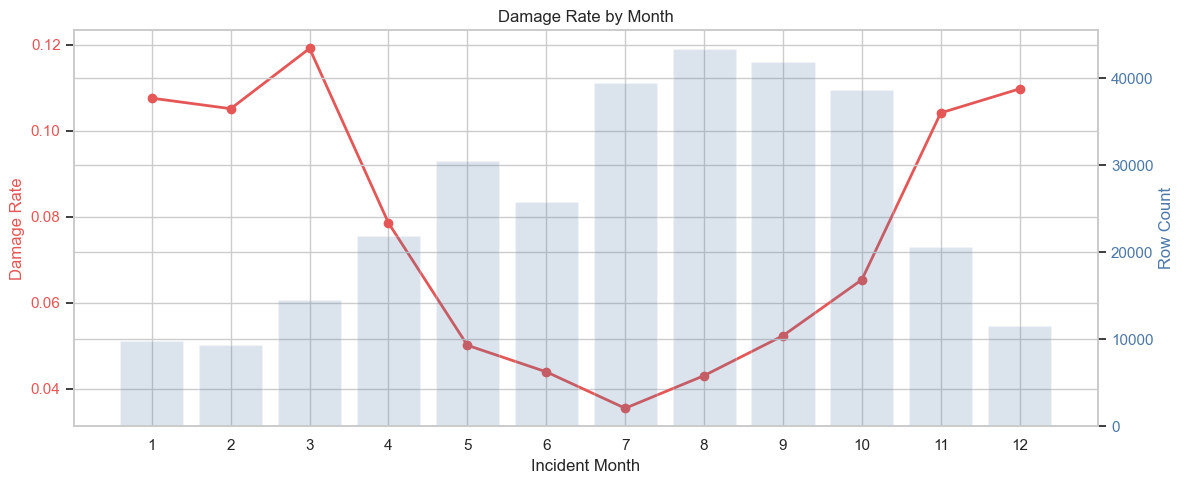

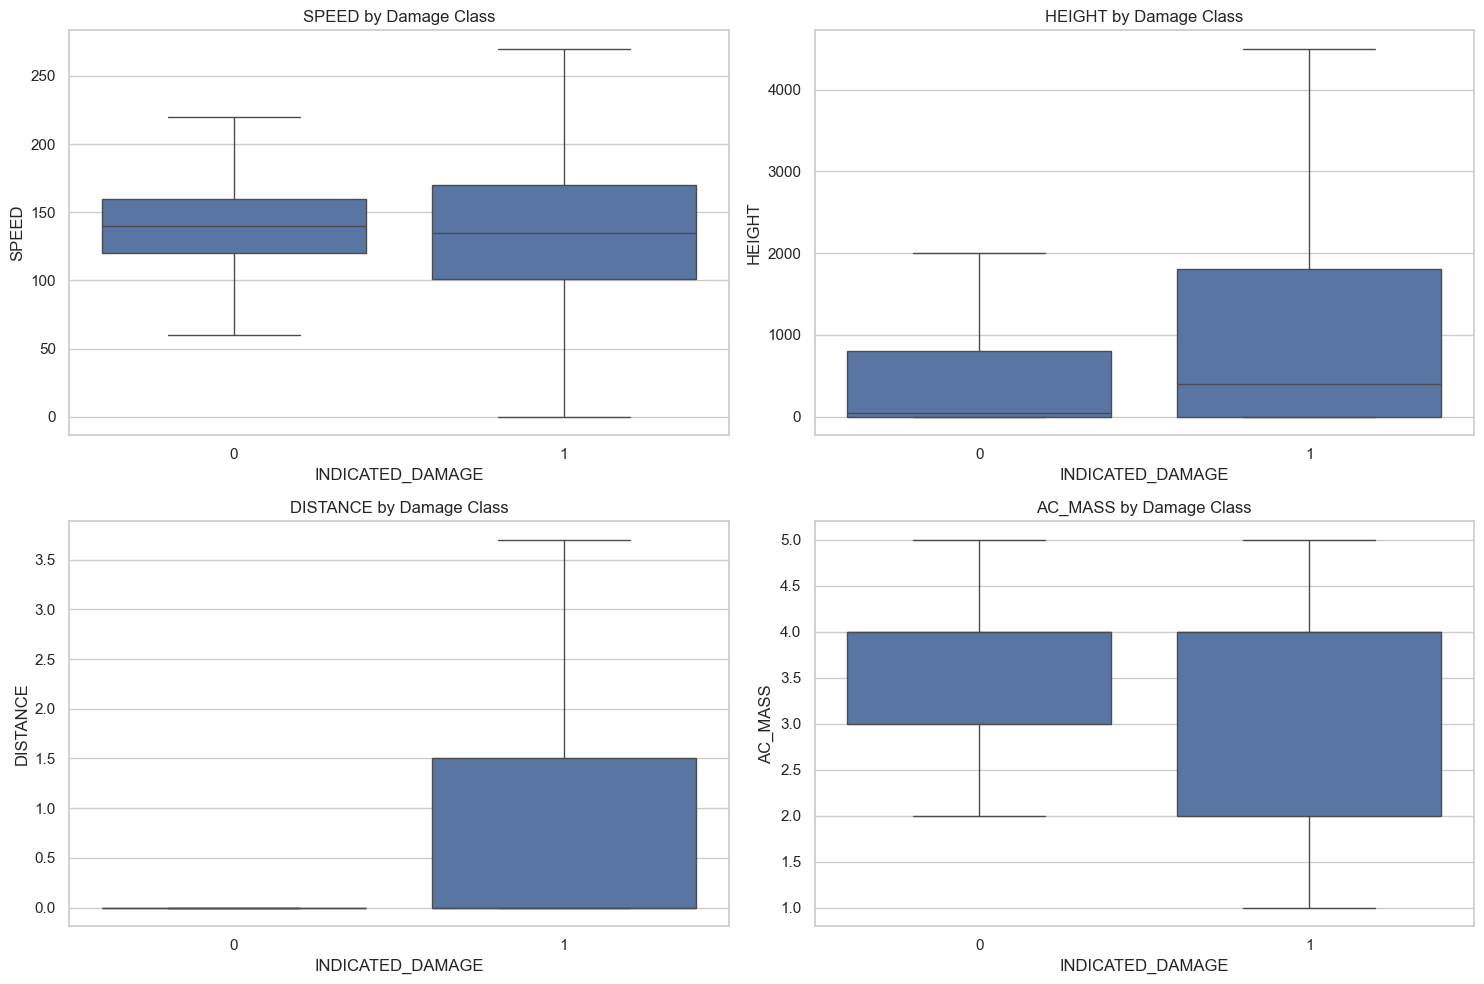

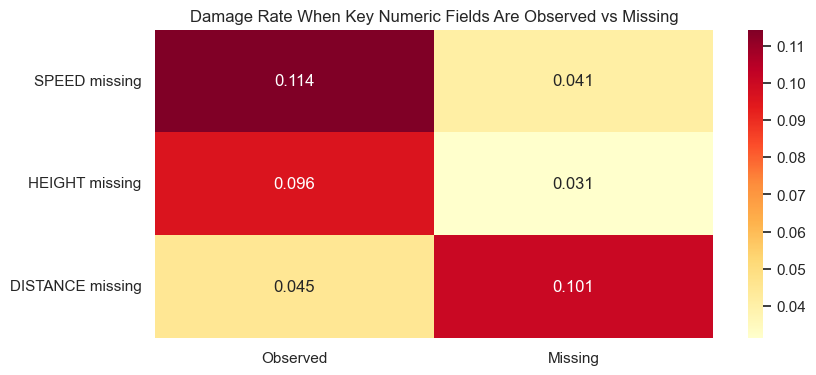

Key EDA takeaways
- The target is highly imbalanced, so balanced accuracy is the right metric to emphasize.
- Flight context variables such as PHASE_OF_FLIGHT, TIME_OF_DAY, SIZE, and decoded NUM_STRUCK show visible differences in damage rate.
- SPEED, HEIGHT, DISTANCE, and AC_MASS show different numeric distributions for damage vs no-damage rows.
- Month-to-month variation supports keeping temporal context and motivates season and cyclical month features.
- Missingness in several numeric strike-condition fields appears non-random, which helps explain the missing-indicator features.


In [3]:
# Build one organized EDA section that combines the original FinalProject plots with the HuiDis exploration plots.
sns.set_theme(style="whitegrid")

eda_columns = [
    "INDICATED_DAMAGE", "LATITUDE", "LONGITUDE", "AC_CLASS", "AC_MASS", "TYPE_ENG", "NUM_ENGS",
    "ENG_1_POS", "ENG_2_POS", "SPEED", "HEIGHT", "DISTANCE", "SIZE", "NUM_STRUCK", "NUM_SEEN",
    "PHASE_OF_FLIGHT", "TIME_OF_DAY", "SKY", "WARNED", "INCIDENT_MONTH", "FAAREGION"
]

eda = train[eda_columns].copy()
for col in ["LATITUDE", "LONGITUDE", "AC_MASS", "NUM_ENGS", "ENG_1_POS", "ENG_2_POS", "SPEED", "HEIGHT", "DISTANCE", "INCIDENT_MONTH"]:
    eda[col] = pd.to_numeric(eda[col], errors="coerce")
for col in ["NUM_SEEN", "NUM_STRUCK"]:
    eda[col] = eda[col].replace({"1": 1, "10-Feb": 2, "2-10": 2, "Feb-10": 2, "11-100": 3, "More than 100": 4})
    eda[col] = pd.to_numeric(eda[col], errors="coerce")
for col in ["AC_CLASS", "TYPE_ENG", "SIZE", "PHASE_OF_FLIGHT", "TIME_OF_DAY", "SKY", "WARNED", "FAAREGION"]:
    eda[col] = eda[col].replace(r"^\s*$", np.nan, regex=True)

print("Training shape:", train.shape)
print("Target damage rate:", round(eda["INDICATED_DAMAGE"].mean(), 4))
display(eda["INDICATED_DAMAGE"].value_counts().rename("count").to_frame())

missing_percent = (train.isna().mean() * 100).sort_values(ascending=False)
print("Top columns by missing percentage")
display(missing_percent.head(20).rename("missing_percent").to_frame())

# HuiDis-style overview figure.
def target_class_balance(ax):
    counts = eda["INDICATED_DAMAGE"].value_counts().sort_index()
    ax.bar(["No Damage", "Damage"], counts.values, color=["steelblue", "tomato"], edgecolor="white")
    ax.set_title("Target Class Balance")
    ax.set_xlabel("Indicated Damage")
    ax.set_ylabel("Count")


def strikes_by_month(ax):
    month_counts = eda.groupby("INCIDENT_MONTH").size().reindex(range(1, 13), fill_value=0)
    month_counts.plot.bar(ax=ax, color="steelblue", edgecolor="white")
    ax.set_title("Strikes by Month")
    ax.set_xlabel("Month")
    ax.set_ylabel("Count")
    ax.set_xticklabels(range(1, 13), rotation=0)


def damage_rate_by_bird_size(ax):
    size_order = ["Small", "Medium", "Large"]
    damage_rate = eda.groupby("SIZE")["INDICATED_DAMAGE"].mean().reindex(size_order) * 100
    damage_rate.plot.bar(ax=ax, color=["steelblue", "orange", "tomato"], edgecolor="white")
    ax.set_title("Damage Rate by Bird Size")
    ax.set_xlabel("Size")
    ax.set_ylabel("Damage Rate (%)")
    ax.tick_params(axis="x", rotation=0)


def damage_rate_by_phase_of_flight(ax):
    phase_rate = eda.groupby("PHASE_OF_FLIGHT")["INDICATED_DAMAGE"].mean().sort_values() * 100
    phase_rate.plot.barh(ax=ax, color="steelblue", edgecolor="white")
    ax.set_title("Damage Rate by Flight Phase")
    ax.set_xlabel("Damage Rate (%)")


def speed_distribution_by_damage(ax):
    for label, damage_value, color in [("No Damage", 0, "steelblue"), ("Damage", 1, "tomato")]:
        values = eda.loc[eda["INDICATED_DAMAGE"] == damage_value, "SPEED"].dropna().clip(0, 400)
        ax.hist(values, bins=40, alpha=0.6, label=label, color=color)
    ax.set_title("Speed Distribution by Damage")
    ax.set_xlabel("Airspeed (knots)")
    ax.set_ylabel("Count")
    ax.legend()


def missing_values_by_column(ax):
    missing_percent.head(15).sort_values().plot.barh(ax=ax, color="steelblue", edgecolor="white")
    ax.set_title("Top 15 Columns by Missing %")
    ax.set_xlabel("Missing (%)")


fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Wildlife Strike Data Exploration", fontsize=16, fontweight="bold")
target_class_balance(axes[0, 0])
strikes_by_month(axes[0, 1])
damage_rate_by_bird_size(axes[0, 2])
damage_rate_by_phase_of_flight(axes[1, 0])
speed_distribution_by_damage(axes[1, 1])
missing_values_by_column(axes[1, 2])
plt.tight_layout()
plt.show()

# Original FinalProject plot: class balance and missingness among the main candidate model fields.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
class_counts = eda["INDICATED_DAMAGE"].value_counts().sort_index()
axes[0].bar(class_counts.index.astype(str), class_counts.values, color=["#4C78A8", "#E45756"])
axes[0].set_title("Target Class Balance")
axes[0].set_xlabel("INDICATED_DAMAGE")
axes[0].set_ylabel("Rows")

missing_candidates = [
    "SPEED", "HEIGHT", "DISTANCE", "NUM_SEEN", "TIME_OF_DAY", "PHASE_OF_FLIGHT", "SKY", "TYPE_ENG", "AC_CLASS"
]
missing_rates = eda[missing_candidates].isna().mean().sort_values()
axes[1].barh(missing_rates.index, missing_rates.values * 100, color="#F58518")
axes[1].set_title("Missingness in Candidate Features")
axes[1].set_xlabel("Percent Missing")
plt.tight_layout()
plt.show()

# Original FinalProject plot: damage rate for key categorical and ordinal variables.
def damage_rate_table(column, min_count=300):
    summary = eda[[column, "INDICATED_DAMAGE"]].copy()
    summary[column] = summary[column].fillna("<MISSING>")
    summary = (
        summary.groupby(column)["INDICATED_DAMAGE"]
        .agg(["size", "mean"])
        .rename(columns={"size": "count", "mean": "damage_rate"})
        .sort_values(["damage_rate", "count"], ascending=[False, False])
    )
    return summary[summary["count"] >= min_count]

plot_columns = ["SIZE", "NUM_STRUCK", "PHASE_OF_FLIGHT", "TIME_OF_DAY"]
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, column in zip(axes.flat, plot_columns):
    summary = damage_rate_table(column).head(8)
    sns.barplot(data=summary.reset_index(), x="damage_rate", y=column, ax=ax, color="#4C78A8")
    ax.set_title(f"Damage Rate by {column}")
    ax.set_xlabel("Damage Rate")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

# Original FinalProject plot: month pattern to motivate season and cyclical month features.
month_damage = eda.groupby("INCIDENT_MONTH")["INDICATED_DAMAGE"].mean()
month_counts = eda.groupby("INCIDENT_MONTH").size()
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(month_damage.index, month_damage.values, marker="o", color="#E45756", linewidth=2)
ax1.set_title("Damage Rate by Month")
ax1.set_xlabel("Incident Month")
ax1.set_ylabel("Damage Rate", color="#E45756")
ax1.tick_params(axis="y", labelcolor="#E45756")
ax1.set_xticks(range(1, 13))

ax2 = ax1.twinx()
ax2.bar(month_counts.index, month_counts.values, alpha=0.2, color="#4C78A8")
ax2.set_ylabel("Row Count", color="#4C78A8")
ax2.tick_params(axis="y", labelcolor="#4C78A8")
plt.tight_layout()
plt.show()

# Original FinalProject plot: numeric signal for variables kept in modeling.
numeric_plot_columns = ["SPEED", "HEIGHT", "DISTANCE", "AC_MASS"]
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, column in zip(axes.flat, numeric_plot_columns):
    subset = eda[[column, "INDICATED_DAMAGE"]].dropna()
    if subset.empty:
        continue
    sampled_subset = subset.groupby("INDICATED_DAMAGE", group_keys=False).apply(
        lambda x: x.sample(min(len(x), 6000), random_state=42)
    )
    sns.boxplot(data=sampled_subset, x="INDICATED_DAMAGE", y=column, ax=ax, showfliers=False)
    ax.set_title(f"{column} by Damage Class")
plt.tight_layout()
plt.show()

# Original FinalProject plot: missingness itself as a possible signal.
missing_signal = pd.DataFrame({
    "SPEED missing": eda.groupby(eda["SPEED"].isna())["INDICATED_DAMAGE"].mean(),
    "HEIGHT missing": eda.groupby(eda["HEIGHT"].isna())["INDICATED_DAMAGE"].mean(),
    "DISTANCE missing": eda.groupby(eda["DISTANCE"].isna())["INDICATED_DAMAGE"].mean(),
}).T
missing_signal.columns = ["Observed", "Missing"]

plt.figure(figsize=(9, 4))
sns.heatmap(missing_signal, annot=True, fmt=".3f", cmap="YlOrRd")
plt.title("Damage Rate When Key Numeric Fields Are Observed vs Missing")
plt.xlabel("")
plt.ylabel("")
plt.show()

print("Key EDA takeaways")
print("- The target is highly imbalanced, so balanced accuracy is the right metric to emphasize.")
print("- Flight context variables such as PHASE_OF_FLIGHT, TIME_OF_DAY, SIZE, and decoded NUM_STRUCK show visible differences in damage rate.")
print("- SPEED, HEIGHT, DISTANCE, and AC_MASS show different numeric distributions for damage vs no-damage rows.")
print("- Month-to-month variation supports keeping temporal context and motivates season and cyclical month features.")
print("- Missingness in several numeric strike-condition fields appears non-random, which helps explain the missing-indicator features.")


## Selected Features for Model Training

The raw FAA wildlife-strike data contains useful signal mixed with columns that are too sparse, too high-cardinality, or too close to free text to be reliable for this project. Based on the latest feedback, we restored raw `HEIGHT`, `SPEED`, and `INCIDENT_MONTH` because tree models can learn their own thresholds from the raw values while still benefiting from engineered interactions and bins.

### Dropped outright or excluded as raw predictors
- `BIRD_BAND_NUMBER`, `ENG_3_POS`, and `ENG_4_POS`: near-total missingness.
- `INDEX_NR`, `LUPDATE`, and `TRANSFER`: identifiers or internal database fields with no useful predictive meaning.
- `REG`, `FLT`, `AIRPORT_ID`, `AIRPORT`, `OPID`, `OPERATOR`, `AMA`, `AMO`, `EMA`, and `EMO`: sparse or high-cardinality identifiers that can memorize training rows or duplicate cleaner aircraft fields.
- `REMARKS`, `COMMENTS`, `LOCATION`, and `ENROUTE_STATE`: free text with heavy missingness.
- `INCIDENT_DATE`: exact date is too granular; we keep `INCIDENT_MONTH`, cyclical month features, `SEASON`, and `INCIDENT_YEAR` instead.
- `SPECIES`: dropped because it duplicates `SPECIES_ID` as a longer text label.
- `ENG_1_POS`, `ENG_2_POS`, and `HAS_WING_MOUNTED_ENGINES`: the raw engine-position fields were sparse, and the simplified wing-mounted-engine flag did not add enough value to keep.
- `REMAINS_COLLECTED` and `REMAINS_SENT`: removed because they may leak post-event investigation information. In the training data, `REMAINS_COLLECTED` has a very different damage rate by value, which makes it suspicious as a predictor for a real pre-reporting prediction task.
- Raw `PRECIPITATION`: about 96% missing, so we replace it with a compact `HAS_PRECIPITATION` flag instead of one-hot encoding a mostly-missing categorical.

### Kept or engineered for the model
- `HEIGHT`, `SPEED`, and `INCIDENT_MONTH`: restored as raw numeric predictors so tree models can find their own thresholds.
- `MONTH_SIN` and `MONTH_COS`: cyclical month encodings so December and January remain close.
- `SPECIES_ID`: reintroduced because it has strong damage-rate separation and only hundreds, not tens of thousands, of categories.
- `AIRCRAFT`: reintroduced because aircraft model captures risk not fully represented by mass and engine count; rare aircraft are grouped by the one-hot encoder.
- `SOURCE` and `PERSON`: reporting/source context. These should be interpreted carefully, but they are structured fields available in both train and test data.
- `SIZE_X_MASS`, `SIZE_X_SPEED`, `SIZE_X_HEIGHT`, `LARGE_BIRD_SMALL_AIRCRAFT`, `HIGH_RISK_ENROUTE`, `STRIKE_RATIO`, `FLOCK_EXPOSURE`, and `WARNED_LARGE_BIRD`: explicit interactions among the strongest domain signals.
- `STATE`, `FAAREGION`, `LATITUDE`, and `LONGITUDE`: geographic signal at multiple levels.
- `SEASON`, `HEIGHT_BAND`, `SPEED_BAND`, and `DISTANCE_BAND`: coarse non-linear summaries that complement the raw numeric values.
- `SPEED_MISSING`, `HEIGHT_MISSING`, and `DISTANCE_MISSING`: missingness indicators retained because the EDA suggested missingness itself is informative.

### Missing data strategy
- Moderate-missing categorical variables are filled with `Unknown` so missingness can remain informative.
- `HEIGHT` and `SPEED` are median-imputed within `PHASE_OF_FLIGHT`; `DISTANCE` is median-imputed globally.
- Rows with missing `INDICATED_DAMAGE` are dropped from training because they cannot be used as labeled examples.


In [5]:
# Raw columns that are allowed into cleaning. Some are used only to build engineered features.
selected_columns = [
    "LATITUDE", "LONGITUDE", "STATE", "FAAREGION",
    "AC_CLASS", "AC_MASS", "TYPE_ENG", "NUM_ENGS", "AIRCRAFT",
    "SPEED", "HEIGHT", "DISTANCE",
    "SIZE", "SPECIES_ID", "NUM_STRUCK", "NUM_SEEN",
    "PHASE_OF_FLIGHT", "TIME_OF_DAY", "SKY", "PRECIPITATION", "WARNED",
    "INCIDENT_MONTH", "INCIDENT_YEAR",
    "SOURCE", "PERSON", "REMAINS_COLLECTED", "REMAINS_SENT",
    "INDICATED_DAMAGE",  # Target variable
]

columns_excluded_as_raw_predictors = [
    "BIRD_BAND_NUMBER", "INDEX_NR", "REG", "FLT", "REMARKS", "COMMENTS", "LOCATION",
    "ENROUTE_STATE", "LUPDATE", "TRANSFER", "INCIDENT_DATE", "AIRPORT_ID", "AIRPORT",
    "OPID", "OPERATOR", "AMA", "AMO", "EMA", "EMO", "SPECIES", "ENG_1_POS", "ENG_2_POS",
    "ENG_3_POS", "ENG_4_POS", "HAS_WING_MOUNTED_ENGINES", "REMAINS_COLLECTED", "REMAINS_SENT",
    "PRECIPITATION",
]

raw_numeric_features = [
    "LATITUDE", "LONGITUDE", "AC_MASS", "NUM_ENGS", "DISTANCE", "INCIDENT_YEAR", "INCIDENT_MONTH",
    "HEIGHT", "SPEED", "NUM_STRUCK", "NUM_SEEN",
]
engineered_numeric_features = [
    "MONTH_SIN", "MONTH_COS", "SPEED_AC_MASS", "HEIGHT_SPEED", "IS_GROUND_STRIKE",
    "MULTI_STRIKE", "IS_LARGE_AIRCRAFT", "SPEED_MISSING", "HEIGHT_MISSING", "DISTANCE_MISSING",
    "SPECIES_ID_FREQ", "AIRCRAFT_FREQ", "STATE_FREQ", "SIZE_NUM", "SIZE_X_MASS", "SIZE_X_SPEED",
    "SIZE_X_HEIGHT", "LARGE_BIRD_SMALL_AIRCRAFT", "HIGH_RISK_ENROUTE", "STRIKE_RATIO",
    "FLOCK_EXPOSURE", "WARNED_LARGE_BIRD", "HAS_PRECIPITATION",
]
numeric_features = raw_numeric_features + engineered_numeric_features
categorical_features = [
    "AC_CLASS", "TYPE_ENG", "AIRCRAFT", "SIZE", "SPECIES_ID", "PHASE_OF_FLIGHT", "TIME_OF_DAY",
    "SKY", "WARNED", "STATE", "FAAREGION", "SEASON", "HEIGHT_BAND", "SPEED_BAND",
    "DISTANCE_BAND", "SOURCE", "PERSON",
]

raw_feature_columns = [col for col in selected_columns if col != "INDICATED_DAMAGE"]
feature_columns = numeric_features + categorical_features

encounter_size_map = {
    "1": 1,
    "10-Feb": 2,
    "2-10": 2,
    "Feb-10": 2,
    "11-100": 3,
    "More than 100": 4,
}

size_order = {
    "Small": 1,
    "Medium": 2,
    "Large": 3,
    "Unknown": 0,
}

phase_numeric_imputation_values = {}
frequency_encoding_maps = {}


def month_to_season(month):
    if pd.isna(month):
        return "Unknown"
    month = int(month)
    if month in [1, 2, 3]:
        return "Winter"
    if month in [4, 5, 6]:
        return "Spring"
    if month in [7, 8, 9]:
        return "Summer"
    if month in [10, 11, 12]:
        return "Fall"
    return "Unknown"


def bin_height(height):
    if pd.isna(height):
        return "Unknown"
    if height == 0:
        return "Ground"
    if height <= 100:
        return "Low"
    if height <= 1000:
        return "Pattern"
    if height <= 5000:
        return "Climb/Descent"
    return "High"


def bin_speed(speed):
    if pd.isna(speed):
        return "Unknown"
    if speed <= 80:
        return "Slow"
    if speed <= 160:
        return "Moderate"
    if speed <= 250:
        return "Fast"
    return "Very Fast"


def bin_distance(distance):
    if pd.isna(distance):
        return "Unknown"
    if distance == 0:
        return "At Airport"
    if distance <= 5:
        return "Near Airport"
    if distance <= 20:
        return "Terminal Area"
    return "Far"


def add_frequency_encodings(cleaned, fit=False):
    global frequency_encoding_maps

    frequency_columns = ["SPECIES_ID", "AIRCRAFT", "STATE"]
    if fit:
        frequency_encoding_maps = {
            col: cleaned[col].value_counts(normalize=True) for col in frequency_columns if col in cleaned.columns
        }

    for col in frequency_columns:
        encoded_col = f"{col}_FREQ"
        if col in cleaned.columns:
            frequency_map = frequency_encoding_maps.get(col, pd.Series(dtype=float))
            cleaned[encoded_col] = cleaned[col].map(frequency_map).fillna(0)
        else:
            cleaned[encoded_col] = 0
    return cleaned


def add_domain_imputations(cleaned, fit=False):
    global phase_numeric_imputation_values

    if fit:
        phase_numeric_imputation_values = {
            "HEIGHT": {
                "group_medians": cleaned.groupby("PHASE_OF_FLIGHT")["HEIGHT"].median(),
                "global_median": cleaned["HEIGHT"].median(),
            },
            "SPEED": {
                "group_medians": cleaned.groupby("PHASE_OF_FLIGHT")["SPEED"].median(),
                "global_median": cleaned["SPEED"].median(),
            },
            "DISTANCE": {
                "global_median": cleaned["DISTANCE"].median(),
            },
        }

    for col in ["HEIGHT", "SPEED"]:
        values = phase_numeric_imputation_values.get(col, {})
        group_medians = values.get("group_medians", pd.Series(dtype=float))
        global_median = values.get("global_median", cleaned[col].median())
        phase_fill_values = cleaned["PHASE_OF_FLIGHT"].map(group_medians)
        cleaned[col] = cleaned[col].fillna(phase_fill_values).fillna(global_median)

    distance_median = phase_numeric_imputation_values.get("DISTANCE", {}).get("global_median", cleaned["DISTANCE"].median())
    cleaned["DISTANCE"] = cleaned["DISTANCE"].fillna(distance_median)
    return cleaned


def clean_feature_frame(df, columns, fit_imputers=False):
    # Copy only the columns we need so later cleaning does not affect the original dataframe.
    cleaned = df[columns].copy()

    # Convert coordinates and numeric strike/aircraft fields to numbers. Any invalid value becomes NaN.
    for col in ["LATITUDE", "LONGITUDE", "AC_MASS", "NUM_ENGS", "SPEED", "HEIGHT", "DISTANCE", "INCIDENT_MONTH", "INCIDENT_YEAR"]:
        if col in cleaned.columns:
            cleaned[col] = pd.to_numeric(cleaned[col], errors="coerce")

    # Collapse mostly missing precipitation into a binary weather flag before categorical imputation.
    if "PRECIPITATION" in cleaned.columns:
        precipitation_values = cleaned["PRECIPITATION"].replace(r"^\s*$", np.nan, regex=True)
        cleaned["HAS_PRECIPITATION"] = (
            precipitation_values.notna()
            & ~precipitation_values.astype(str).str.strip().isin(["None", "Unknown", "nan", ""])
        ).astype(int)
    else:
        cleaned["HAS_PRECIPITATION"] = 0

    # Excel-misread encounter ranges become ordinal numeric values.
    for col in ["NUM_SEEN", "NUM_STRUCK"]:
        if col in cleaned.columns:
            cleaned[col] = cleaned[col].replace(encounter_size_map)
            cleaned[col] = pd.to_numeric(cleaned[col], errors="coerce")

    # Treat blank categorical values as missing and preserve missingness as its own category.
    for col in categorical_features:
        if col in cleaned.columns:
            cleaned[col] = cleaned[col].replace(r"^\s*$", np.nan, regex=True).fillna("Unknown").astype(str).str.strip()

    # Missingness appears informative for several sparse strike-condition fields.
    for col in ["SPEED", "HEIGHT", "DISTANCE"]:
        cleaned[f"{col}_MISSING"] = cleaned[col].isna().astype(int) if col in cleaned.columns else 1

    # Frequency encodings let trees use how common high-cardinality values are without relying only on one-hot splits.
    cleaned = add_frequency_encodings(cleaned, fit=fit_imputers)

    # Phase-aware numeric imputation reflects that height/speed mean different things in different flight phases.
    cleaned = add_domain_imputations(cleaned, fit=fit_imputers)

    # Domain feature engineering. Raw HEIGHT, SPEED, and INCIDENT_MONTH remain final predictors too.
    cleaned["MONTH_SIN"] = np.sin(2 * np.pi * cleaned["INCIDENT_MONTH"] / 12)
    cleaned["MONTH_COS"] = np.cos(2 * np.pi * cleaned["INCIDENT_MONTH"] / 12)
    cleaned["SPEED_AC_MASS"] = cleaned["SPEED"] * cleaned["AC_MASS"]
    cleaned["HEIGHT_SPEED"] = cleaned["HEIGHT"] * cleaned["SPEED"]
    cleaned["SEASON"] = cleaned["INCIDENT_MONTH"].apply(month_to_season)
    cleaned["HEIGHT_BAND"] = cleaned["HEIGHT"].apply(bin_height)
    cleaned["SPEED_BAND"] = cleaned["SPEED"].apply(bin_speed)
    cleaned["DISTANCE_BAND"] = cleaned["DISTANCE"].apply(bin_distance)
    cleaned["SIZE_NUM"] = cleaned["SIZE"].map(size_order).fillna(0)
    cleaned["SIZE_X_MASS"] = cleaned["SIZE_NUM"] * cleaned["AC_MASS"]
    cleaned["SIZE_X_SPEED"] = cleaned["SIZE_NUM"] * cleaned["SPEED"]
    cleaned["SIZE_X_HEIGHT"] = cleaned["SIZE_NUM"] * cleaned["HEIGHT"]
    cleaned["LARGE_BIRD_SMALL_AIRCRAFT"] = ((cleaned["SIZE"] == "Large") & (cleaned["AC_MASS"] <= 2)).astype(int)
    cleaned["HIGH_RISK_ENROUTE"] = ((cleaned["HEIGHT"] > 1000) & (cleaned["SPEED"] > 200)).astype(int)
    cleaned["STRIKE_RATIO"] = cleaned["NUM_STRUCK"] / (cleaned["NUM_SEEN"] + 1)
    cleaned["FLOCK_EXPOSURE"] = cleaned["NUM_SEEN"] * cleaned["NUM_STRUCK"]
    cleaned["WARNED_LARGE_BIRD"] = ((cleaned["WARNED"] == "No") & (cleaned["SIZE"] == "Large")).astype(int)
    cleaned["IS_GROUND_STRIKE"] = (cleaned["HEIGHT"] == 0).astype(int)
    cleaned["MULTI_STRIKE"] = (cleaned["NUM_STRUCK"] > 1).astype(int)
    cleaned["IS_LARGE_AIRCRAFT"] = (cleaned["AC_MASS"] >= 4).astype(int)

    return cleaned


def prepare_training_data(df):
    # Clean the training columns first so missing and malformed values are standardized.
    cleaned = clean_feature_frame(df, selected_columns, fit_imputers=True)

    # Drop rows only when the target is missing. Feature NaNs will be handled in the model pipeline.
    cleaned = cleaned.dropna(subset=["INDICATED_DAMAGE"]).copy()
    return cleaned[feature_columns + ["INDICATED_DAMAGE"]]


def prepare_prediction_data(df):
    # Clean the test features but keep rows with missing feature values for the imputer to fill.
    cleaned = clean_feature_frame(df, raw_feature_columns, fit_imputers=False)
    return cleaned[feature_columns]


# Build the cleaned training dataset that will be used for splitting and fitting.
train_clean = prepare_training_data(train)

# Take a quick look at the cleaned training data.
print("Excluded raw predictor columns:", columns_excluded_as_raw_predictors)
print(train_clean.shape)
print(train_clean.head())
print(train_clean.dtypes)


Excluded raw predictor columns: ['BIRD_BAND_NUMBER', 'INDEX_NR', 'REG', 'FLT', 'REMARKS', 'COMMENTS', 'LOCATION', 'ENROUTE_STATE', 'LUPDATE', 'TRANSFER', 'INCIDENT_DATE', 'AIRPORT_ID', 'AIRPORT', 'OPID', 'OPERATOR', 'AMA', 'AMO', 'EMA', 'EMO', 'SPECIES', 'ENG_1_POS', 'ENG_2_POS', 'ENG_3_POS', 'ENG_4_POS', 'HAS_WING_MOUNTED_ENGINES', 'REMAINS_COLLECTED', 'REMAINS_SENT', 'PRECIPITATION']
(307178, 52)
    LATITUDE   LONGITUDE  AC_MASS  NUM_ENGS  DISTANCE  INCIDENT_YEAR  \
0  18.439420  -66.001830      4.0       3.0       0.0           1993   
1   2.745578  101.709917      4.0       3.0       0.0           2010   
2  38.174390  -85.736000      4.0       2.0       8.0           2012   
3  33.942540 -118.408070      NaN       NaN       0.0           2002   
4  21.975980 -159.338960      4.0       2.0       0.0           1997   

   INCIDENT_MONTH  HEIGHT  SPEED  NUM_STRUCK  NUM_SEEN     MONTH_SIN  \
0              12   300.0  145.0         2.0       2.0 -2.449294e-16   
1               2    

## Feature Engineering Summary

The final feature set reflects several rounds of trial and simplification. Based on the latest feedback, we restored raw `HEIGHT`, `SPEED`, and `INCIDENT_MONTH` because tree models can learn their own thresholds from the raw values. We still keep the engineered versions: `HEIGHT_SPEED`, `SPEED_AC_MASS`, `HEIGHT_BAND`, `SPEED_BAND`, `DISTANCE_BAND`, `MONTH_SIN`, `MONTH_COS`, and `SEASON`.

We also added stronger domain interactions between the most important signals: `SIZE_X_MASS`, `SIZE_X_SPEED`, `SIZE_X_HEIGHT`, `LARGE_BIRD_SMALL_AIRCRAFT`, `HIGH_RISK_ENROUTE`, `STRIKE_RATIO`, `FLOCK_EXPOSURE`, and `WARNED_LARGE_BIRD`. These features directly describe situations that should change damage risk, such as a large animal hitting a smaller aircraft, a fast high-altitude strike, or many birds being struck out of a larger flock.

`PRECIPITATION` was collapsed into `HAS_PRECIPITATION` because the raw column is mostly missing. `REMAINS_COLLECTED` and `REMAINS_SENT` were removed from predictors because they may leak post-event investigation information; the training data shows noticeably different damage rates by remains status, especially for `REMAINS_COLLECTED`.


## Recent Improvement Notes

The previous feature-engineering pass improved balanced accuracy by about one percentage point, mostly for the decision-tree-style models. The helpful changes were adding back high-signal structured fields (`SPECIES_ID`, `AIRCRAFT`, `SOURCE`, `PERSON`, `PRECIPITATION`, `STATE`, and `INCIDENT_YEAR`), adding binned strike-context features (`HEIGHT_BAND`, `SPEED_BAND`, and `DISTANCE_BAND`), and tuning the classification threshold on validation probabilities instead of using the default `0.50` cutoff.

This pass implements the latest feedback: raw `HEIGHT`, raw `SPEED`, and raw `INCIDENT_MONTH` are back; month also gets cyclical encoding; animal-size interactions are added; strike-count ratio/exposure features are added; warning is crossed with large-bird encounters; precipitation is converted to a binary flag; and possible remains-related leakage features are dropped.


## Model Training and Comparison

The models below were chosen for an imbalanced tabular classification problem. Decision trees and tree ensembles handle mixed numeric/categorical features well and can model non-linear relationships such as high-speed strikes on heavier aircraft. Random Forest and Extra Trees reduce the instability of a single tree by averaging many trees, while the histogram gradient-boosted model adds a stronger boosting-style learner that is more memory-efficient with categorical features than dense neural-network one-hot encoding.

We intentionally avoided models that rely heavily on proximity or distance in the raw feature space, such as k-nearest neighbors, because one-hot encoded categorical data can make distance less meaningful and high dimensionality can weaken neighborhood-based methods. The chosen models either use class weighting, sample weighting, resampling, threshold tuning, or tree splits that are more appropriate for the imbalance and feature mix in this dataset.

The decision-tree search previously crashed the kernel after the feature set grew, because cross-validation repeatedly rebuilt a large one-hot encoded matrix. To keep the notebook runnable, the decision tree now uses fixed conservative hyperparameters plus validation-threshold tuning. The forest models also use fixed settings for the same reason. The boosted tree uses the same fixed base-tree structure, and the neural network uses oversampling and threshold tuning because its default behavior can produce high accuracy but poor balanced accuracy on imbalanced data.


## Decision Tree

The first model is a single decision tree with fixed, conservative hyperparameters. We previously tried randomized hyperparameter tuning, but after adding the larger feature set it repeatedly crashed the kernel because cross-validation had to rebuild a large one-hot encoded matrix many times. To keep the notebook stable, this section uses one fixed tree and tunes only the validation probability threshold, which is cheap and directly improves balanced accuracy.
        


In [6]:
# Split the cleaned data into features and target
X = train_clean.drop(columns="INDICATED_DAMAGE")
y = train_clean["INDICATED_DAMAGE"]

# Hold out part of the training data for evaluation.
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

model_results = []


def find_best_threshold(y_true, probabilities):
    threshold_scores = []
    for threshold in np.linspace(0.01, 0.99, 981):
        predictions = (probabilities >= threshold).astype(int)
        threshold_scores.append((balanced_accuracy_score(y_true, predictions), threshold))
    return max(threshold_scores, key=lambda item: item[0])


def evaluate_model(model_name, y_true, predictions, probabilities, threshold=None):
    metrics = {
        "Model": model_name,
        "Threshold": threshold if threshold is not None else 0.5,
        "Accuracy": accuracy_score(y_true, predictions),
        "Balanced Accuracy": balanced_accuracy_score(y_true, predictions),
        "Precision": precision_score(y_true, predictions, zero_division=0),
        "Recall": recall_score(y_true, predictions, zero_division=0),
        "F1 Score": f1_score(y_true, predictions, zero_division=0),
        "ROC AUC": roc_auc_score(y_true, probabilities),
    }
    model_results.append(metrics)

    print(f"{model_name} Evaluation Results")
    if threshold is not None:
        print(f"{'Threshold:':<20}{threshold:.3f}")
    for metric_name in ["Accuracy", "Balanced Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]:
        print(f"{metric_name + ':':<20}{metrics[metric_name]:.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, predictions))
    print("\nClassification Report:")
    print(classification_report(y_true, predictions, zero_division=0))
    return metrics


# Numeric values have already received domain-aware imputation where requested; this catches any remaining NaNs.
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

# Preserve missing categorical values as Unknown, then one-hot encode them.
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=25)),
    ]
)

# Apply the numeric and categorical preprocessing so train, validation, and test are handled the same way.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Build the decision tree pipeline so preprocessing and prediction stay connected.
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                criterion="gini",
                max_depth=14,
                min_samples_split=50,
                min_samples_leaf=25,
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)

# Fit the fixed decision tree on the training split.
decision_tree_model.fit(X_train, y_train)

# Predict probabilities on the validation split and tune the threshold for balanced accuracy.
dt_val_probabilities = decision_tree_model.predict_proba(X_val)[:, 1]
dt_best_balanced_accuracy, dt_threshold = find_best_threshold(y_val, dt_val_probabilities)
dt_val_predictions = (dt_val_probabilities >= dt_threshold).astype(int)
evaluate_model("Decision Tree", y_val, dt_val_predictions, dt_val_probabilities, threshold=dt_threshold)

# Retrain the fixed tree on all cleaned training rows before making final test predictions.
decision_tree_model.fit(X, y)

# Load the test data and keep every row so the model predicts on the full submission set.
test_data = pd.read_csv("test.csv", low_memory=False)
X_test = prepare_prediction_data(test_data)

# Generate thresholded predictions for every test row after the pipeline fills missing values.
dt_test_probabilities = decision_tree_model.predict_proba(X_test)[:, 1]
dt_test_predictions = (dt_test_probabilities >= dt_threshold).astype(int)

# Build and save the decision tree submission file.
decision_tree_submission = test_data[["INDEX_NR"]].copy()
decision_tree_submission["INDICATED_DAMAGE"] = dt_test_predictions
decision_tree_submission.to_csv("decision_tree_submission.csv", index=False)
print("Saved submission file to decision_tree_submission.csv")
        


Decision Tree Evaluation Results
Threshold:          0.433
Accuracy:           0.7925
Balanced Accuracy:  0.7942
Precision:          0.2064
Recall:             0.7962
F1 Score:           0.3278
ROC AUC:            0.8617

Confusion Matrix:
[[45577 11954]
 [  796  3109]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.79      0.88     57531
           1       0.21      0.80      0.33      3905

    accuracy                           0.79     61436
   macro avg       0.59      0.79      0.60     61436
weighted avg       0.93      0.79      0.84     61436

Saved submission file to decision_tree_submission.csv


## Random Forest

Random Forest averages many decision trees to reduce variance while keeping the advantages of tree-based modeling on one-hot encoded tabular data. We use `class_weight="balanced_subsample"` so each tree pays more attention to the minority damage class.

We intentionally do not run hyperparameter tuning here. The Random Forest search was causing kernel crashes, and the tuned decision tree did not show enough improvement to justify a much more expensive forest search. The fixed settings below are a conservative compromise: enough trees for stability, bounded depth and leaf size to reduce overfitting, and limited parallelism to keep memory use under control.


In [7]:
# Build the random forest pipeline using fixed settings to avoid expensive searches that crash the kernel.
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=250,
                max_depth=18,
                min_samples_leaf=8,
                max_features="sqrt",
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=2,
            ),
        ),
    ]
)

# Fit the random forest on the training split.
random_forest_model.fit(X_train, y_train)

# Predict probabilities on the validation split and tune the threshold for balanced accuracy.
rf_val_probabilities = random_forest_model.predict_proba(X_val)[:, 1]
rf_best_balanced_accuracy, rf_threshold = find_best_threshold(y_val, rf_val_probabilities)
rf_val_predictions = (rf_val_probabilities >= rf_threshold).astype(int)
evaluate_model("Random Forest", y_val, rf_val_predictions, rf_val_probabilities, threshold=rf_threshold)

# Retrain the random forest on all cleaned training rows.
random_forest_model.fit(X, y)

# Generate thresholded predictions for every test row using the same imputation pipeline.
rf_test_probabilities = random_forest_model.predict_proba(X_test)[:, 1]
rf_test_predictions = (rf_test_probabilities >= rf_threshold).astype(int)

# Build and save the random forest submission file.
random_forest_submission = test_data[["INDEX_NR"]].copy()
random_forest_submission["INDICATED_DAMAGE"] = rf_test_predictions
random_forest_submission.to_csv("random_forest_submission.csv", index=False)
print("Saved submission file to random_forest_submission.csv")
        


Random Forest Evaluation Results
Threshold:          0.444
Accuracy:           0.8065
Balanced Accuracy:  0.8143
Precision:          0.2230
Recall:             0.8233
F1 Score:           0.3510
ROC AUC:            0.9008

Confusion Matrix:
[[46332 11199]
 [  690  3215]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.81      0.89     57531
           1       0.22      0.82      0.35      3905

    accuracy                           0.81     61436
   macro avg       0.60      0.81      0.62     61436
weighted avg       0.94      0.81      0.85     61436

Saved submission file to random_forest_submission.csv


## Extremely Randomized Forest

An extremely randomized forest (`ExtraTreesClassifier`) is another tree ensemble. It adds more randomness than a standard random forest when choosing split thresholds, which can reduce variance and sometimes improves generalization on noisy tabular data.

Like Random Forest, this model is not tuned in this notebook. Extra Trees is already computationally heavy on a large one-hot encoded dataset, and the earlier decision-tree tuning did not produce enough improvement to make an expensive Extra Trees search worthwhile. We keep fixed, class-weighted settings so the notebook can run reliably.


In [8]:
# Build an extremely randomized forest pipeline using fixed settings for reliability.
extra_trees_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            ExtraTreesClassifier(
                n_estimators=250,
                max_depth=18,
                min_samples_leaf=8,
                max_features="sqrt",
                class_weight="balanced",
                random_state=42,
                n_jobs=2,
            ),
        ),
    ]
)

# Fit the Extra Trees model on the training split.
extra_trees_model.fit(X_train, y_train)

# Predict probabilities on the validation split and tune the threshold for balanced accuracy.
et_val_probabilities = extra_trees_model.predict_proba(X_val)[:, 1]
et_best_balanced_accuracy, et_threshold = find_best_threshold(y_val, et_val_probabilities)
et_val_predictions = (et_val_probabilities >= et_threshold).astype(int)
evaluate_model("Extra Trees", y_val, et_val_predictions, et_val_probabilities, threshold=et_threshold)

# Retrain the Extra Trees model on all cleaned training rows.
extra_trees_model.fit(X, y)

# Generate thresholded predictions for every test row using the same preprocessing pipeline.
et_test_probabilities = extra_trees_model.predict_proba(X_test)[:, 1]
et_test_predictions = (et_test_probabilities >= et_threshold).astype(int)

# Build and save the Extra Trees submission file.
extra_trees_submission = test_data[["INDEX_NR"]].copy()
extra_trees_submission["INDICATED_DAMAGE"] = et_test_predictions
extra_trees_submission.to_csv("extra_trees_submission.csv", index=False)
print("Saved submission file to extra_trees_submission.csv")


Extra Trees Evaluation Results
Threshold:          0.490
Accuracy:           0.8095
Balanced Accuracy:  0.8127
Precision:          0.2250
Recall:             0.8164
F1 Score:           0.3527
ROC AUC:            0.9003

Confusion Matrix:
[[46547 10984]
 [  717  3188]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.81      0.89     57531
           1       0.22      0.82      0.35      3905

    accuracy                           0.81     61436
   macro avg       0.60      0.81      0.62     61436
weighted avg       0.94      0.81      0.85     61436

Saved submission file to extra_trees_submission.csv


## Histogram Gradient-Boosted Tree

This model is a new attempt to improve balanced accuracy without blowing up memory. It uses `HistGradientBoostingClassifier`, which can learn non-linear interactions like the tree ensembles but uses ordinal-encoded categorical variables instead of a large sparse one-hot matrix. We use the best compact configuration found during local validation, pass class-balanced sample weights, and tune the validation threshold for balanced accuracy.


In [9]:
# Build a memory-friendlier gradient-boosted tree model with ordinal-encoded categoricals.
hgb_numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

hgb_categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ]
)

hgb_preprocessor = ColumnTransformer(
    transformers=[
        ("num", hgb_numeric_transformer, numeric_features),
        ("cat", hgb_categorical_transformer, categorical_features),
    ],
)

hist_gradient_model = Pipeline(
    steps=[
        ("preprocessor", hgb_preprocessor),
        (
            "classifier",
            HistGradientBoostingClassifier(
                max_iter=300,
                learning_rate=0.05,
                max_leaf_nodes=31,
                min_samples_leaf=35,
                l2_regularization=0.2,
                random_state=42,
            ),
        ),
    ]
)


# The local search found that a very small reduction in positive-class weight worked best.
hgb_positive_weight_multiplier = 0.95


def make_hgb_weights(y_values, positive_weight_multiplier):
    weights = compute_sample_weight(class_weight="balanced", y=y_values)
    weights[np.asarray(y_values) == 1] *= positive_weight_multiplier
    return weights


# Fit with class-balanced sample weights and tune the validation threshold for balanced accuracy.
hgb_train_weights = make_hgb_weights(y_train, hgb_positive_weight_multiplier)
hist_gradient_model.fit(X_train, y_train, classifier__sample_weight=hgb_train_weights)

hgb_val_probabilities = hist_gradient_model.predict_proba(X_val)[:, 1]
hgb_best_balanced_accuracy, hgb_threshold = find_best_threshold(y_val, hgb_val_probabilities)
hgb_val_predictions = (hgb_val_probabilities >= hgb_threshold).astype(int)
evaluate_model("Histogram Gradient Boosting", y_val, hgb_val_predictions, hgb_val_probabilities, threshold=hgb_threshold)

# Retrain on all cleaned training rows before making final test predictions.
hgb_all_weights = make_hgb_weights(y, hgb_positive_weight_multiplier)
hist_gradient_model.fit(X, y, classifier__sample_weight=hgb_all_weights)

# Generate thresholded predictions for every test row.
hgb_test_probabilities = hist_gradient_model.predict_proba(X_test)[:, 1]
hgb_test_predictions = (hgb_test_probabilities >= hgb_threshold).astype(int)

# Build and save the histogram-gradient-boosting submission file.
hgb_submission = test_data[["INDEX_NR"]].copy()
hgb_submission["INDICATED_DAMAGE"] = hgb_test_predictions
hgb_submission.to_csv("hist_gradient_boosting_submission.csv", index=False)
print("Saved submission file to hist_gradient_boosting_submission.csv")


Histogram Gradient Boosting Evaluation Results
Threshold:          0.439
Accuracy:           0.8109
Balanced Accuracy:  0.8278
Precision:          0.2309
Recall:             0.8471
F1 Score:           0.3629
ROC AUC:            0.9123

Confusion Matrix:
[[46511 11020]
 [  597  3308]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.81      0.89     57531
           1       0.23      0.85      0.36      3905

    accuracy                           0.81     61436
   macro avg       0.61      0.83      0.63     61436
weighted avg       0.94      0.81      0.86     61436

Saved submission file to hist_gradient_boosting_submission.csv


## HGB Hyperparameter Tuning with RandomizedSearchCV

The fixed HGB configuration above was chosen based on prior manual testing but was never searched. This section runs `RandomizedSearchCV` to try 20 random combinations of learning rate, tree shape, and regularization strength. We reuse the same encoded preprocessor so each cross-validation fold does not need to rebuild a large one-hot matrix, keeping the search fast.

`RandomizedSearchCV` does not support per-fold `sample_weight` cleanly, so the search scores on balanced accuracy rather than using explicit class weights. The best configuration is retrained on all data with sample weights to match the approach used for the fixed model.

In [10]:
from sklearn.model_selection import RandomizedSearchCV

hgb_param_dist = {
    "classifier__learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "classifier__max_leaf_nodes": [20, 31, 50, 63],
    "classifier__min_samples_leaf": [15, 25, 35, 50],
    "classifier__l2_regularization": [0.0, 0.1, 0.2, 0.5],
    "classifier__max_iter": [200, 300, 400],
}

hgb_search_pipeline = Pipeline(
    steps=[
        ("preprocessor", hgb_preprocessor),
        ("classifier", HistGradientBoostingClassifier(random_state=42)),
    ]
)

hgb_search = RandomizedSearchCV(
    hgb_search_pipeline,
    param_distributions=hgb_param_dist,
    n_iter=20,
    cv=3,
    scoring="balanced_accuracy",
    n_jobs=2,
    random_state=42,
    verbose=1,
)

hgb_search.fit(X_train, y_train)

print("Best HGB parameters found by search:")
for param, value in sorted(hgb_search.best_params_.items()):
    print(f"  {param}: {value}")
print(f"Best CV balanced accuracy: {hgb_search.best_score_:.4f}")

# Evaluate the best found pipeline on the held-out validation set.
hgb_tuned_val_probabilities = hgb_search.predict_proba(X_val)[:, 1]
hgb_tuned_best_ba, hgb_tuned_threshold = find_best_threshold(y_val, hgb_tuned_val_probabilities)
hgb_tuned_val_predictions = (hgb_tuned_val_probabilities >= hgb_tuned_threshold).astype(int)
evaluate_model("HGB Tuned", y_val, hgb_tuned_val_predictions, hgb_tuned_val_probabilities, threshold=hgb_tuned_threshold)

# Retrain the best configuration on all training data using a fresh pipeline with sample weights.
best_hgb_params = {k.replace("classifier__", ""): v for k, v in hgb_search.best_params_.items()}
hgb_tuned_final = Pipeline(
    steps=[
        (
            "preprocessor",
            ColumnTransformer(
                transformers=[
                    ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_features),
                    (
                        "cat",
                        Pipeline([
                            ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
                            ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
                        ]),
                        categorical_features,
                    ),
                ],
            ),
        ),
        ("classifier", HistGradientBoostingClassifier(random_state=42, **best_hgb_params)),
    ]
)
hgb_tuned_weights = make_hgb_weights(y, hgb_positive_weight_multiplier)
hgb_tuned_final.fit(X, y, classifier__sample_weight=hgb_tuned_weights)

hgb_tuned_test_probabilities = hgb_tuned_final.predict_proba(X_test)[:, 1]
hgb_tuned_test_predictions = (hgb_tuned_test_probabilities >= hgb_tuned_threshold).astype(int)

hgb_tuned_submission = test_data[["INDEX_NR"]].copy()
hgb_tuned_submission["INDICATED_DAMAGE"] = hgb_tuned_test_predictions
hgb_tuned_submission.to_csv("hist_gradient_boosting_tuned_submission.csv", index=False)
print("Saved submission file to hist_gradient_boosting_tuned_submission.csv")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best HGB parameters found by search:
  classifier__l2_regularization: 0.5
  classifier__learning_rate: 0.08
  classifier__max_iter: 200
  classifier__max_leaf_nodes: 63
  classifier__min_samples_leaf: 35
Best CV balanced accuracy: 0.6577
HGB Tuned Evaluation Results
Threshold:          0.063
Accuracy:           0.8268
Balanced Accuracy:  0.8285
Precision:          0.2453
Recall:             0.8305
F1 Score:           0.3787
ROC AUC:            0.9128

Confusion Matrix:
[[47552  9979]
 [  662  3243]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.83      0.90     57531
           1       0.25      0.83      0.38      3905

    accuracy                           0.83     61436
   macro avg       0.62      0.83      0.64     61436
weighted avg       0.94      0.83      0.87     61436

Saved submission file to hist_gradient_boosting_tuned_submission.csv


## LightGBM

LightGBM is a gradient boosting framework that is usually faster and has more efficient memory-usage than standard gradient boosted trees. It uses a histogram-based split finding algorithm (similar to `HistGradientBoostingClassifier`) but adds tree growth leaf-wise and GOSS (Gradient-based One-Side Sampling), which can find better splits on large datasets by at each step finding whichever single leaf across the entire tree would gain the most from being split.

We use encoded categoricals (same as HGB) so the model does not need a large one-hot matrix, and `class_weight="balanced"` so it pays attention to the minority damage class.

In [11]:
# Install LightGBM if not already present in this environment.
try:
    import lightgbm as lgb
    print(f"LightGBM {lgb.__version__} already installed.")
except ImportError:
    print("Installing LightGBM...")
    import subprocess
    subprocess.run(["pip", "install", "lightgbm", "--quiet"], check=True)
    import lightgbm as lgb
    print(f"LightGBM {lgb.__version__} installed.")

LightGBM 4.6.0 already installed.


In [12]:
import lightgbm as lgb

# Use ordinal encoding like HGB — much more memory-efficient than one-hot for LightGBM.
lgb_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_features),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
                ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
            ]),
            categorical_features,
        ),
    ],
)

lgb_model = Pipeline(
    steps=[
        ("preprocessor", lgb_preprocessor),
        (
            "classifier",
            lgb.LGBMClassifier(
                n_estimators=500,
                learning_rate=0.05,
                num_leaves=63,
                min_child_samples=30,
                class_weight="balanced",
                random_state=42,
                n_jobs=2,
                verbose=-1,
            ),
        ),
    ]
)

lgb_model.fit(X_train, y_train)

lgb_val_probabilities = lgb_model.predict_proba(X_val)[:, 1]
lgb_best_ba, lgb_threshold = find_best_threshold(y_val, lgb_val_probabilities)
lgb_val_predictions = (lgb_val_probabilities >= lgb_threshold).astype(int)
evaluate_model("LightGBM", y_val, lgb_val_predictions, lgb_val_probabilities, threshold=lgb_threshold)

# Retrain on all cleaned training rows before making final test predictions.
lgb_model.fit(X, y)

lgb_test_probabilities = lgb_model.predict_proba(X_test)[:, 1]
lgb_test_predictions = (lgb_test_probabilities >= lgb_threshold).astype(int)

lgb_submission = test_data[["INDEX_NR"]].copy()
lgb_submission["INDICATED_DAMAGE"] = lgb_test_predictions
lgb_submission.to_csv("lightgbm_submission.csv", index=False)
print("Saved submission file to lightgbm_submission.csv")

LightGBM Evaluation Results
Threshold:          0.449
Accuracy:           0.8386
Balanced Accuracy:  0.8270
Precision:          0.2569
Recall:             0.8138
F1 Score:           0.3906
ROC AUC:            0.9113

Confusion Matrix:
[[48340  9191]
 [  727  3178]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.84      0.91     57531
           1       0.26      0.81      0.39      3905

    accuracy                           0.84     61436
   macro avg       0.62      0.83      0.65     61436
weighted avg       0.94      0.84      0.87     61436

Saved submission file to lightgbm_submission.csv


## Boosted Tree With Fixed Decision-Tree Base

AdaBoost fits decision trees sequentially so later trees focus more on examples earlier trees handled poorly. We include it because it gives a different tree-based comparison from bagging ensembles like Random Forest and Extra Trees.

This section uses the same fixed decision-tree structure as the lone decision tree rather than using another hyperparameter search. This keeps the notebook light and avoids the kernel crashes caused by repeated cross-validation over the expanded one-hot feature set.


In [14]:
# Use the same fixed tree structure as the standalone decision tree as AdaBoost's base estimator.
boosted_base_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4, #14 before
    min_samples_split=50,
    min_samples_leaf=25,
    class_weight="balanced",
    random_state=42,
)

print("Boosted tree base estimator parameters:")
print({
    "criterion": boosted_base_tree.criterion,
    "max_depth": boosted_base_tree.max_depth,
    "min_samples_split": boosted_base_tree.min_samples_split,
    "min_samples_leaf": boosted_base_tree.min_samples_leaf,
    "class_weight": boosted_base_tree.class_weight,
})

# Build a boosted tree pipeline using the fixed decision tree as the base estimator.
boosted_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            AdaBoostClassifier(
                estimator=boosted_base_tree,
                n_estimators=100, #150 before
                learning_rate=0.05,
                random_state=42,
            ),
        ),
    ]
)

# Fit the boosted tree model on the training split.
boosted_tree_model.fit(X_train, y_train)

# Predict probabilities on the validation split and tune the threshold for balanced accuracy.
bt_val_probabilities = boosted_tree_model.predict_proba(X_val)[:, 1]
bt_best_balanced_accuracy, bt_threshold = find_best_threshold(y_val, bt_val_probabilities)
bt_val_predictions = (bt_val_probabilities >= bt_threshold).astype(int)
evaluate_model("Boosted Tree", y_val, bt_val_predictions, bt_val_probabilities, threshold=bt_threshold)

# Retrain the boosted tree model on all cleaned training rows.
boosted_tree_model.fit(X, y)

# Generate thresholded predictions for every test row using the same preprocessing pipeline.
bt_test_probabilities = boosted_tree_model.predict_proba(X_test)[:, 1]
bt_test_predictions = (bt_test_probabilities >= bt_threshold).astype(int)

# Build and save the boosted-tree submission file.
boosted_tree_submission = test_data[["INDEX_NR"]].copy()
boosted_tree_submission["INDICATED_DAMAGE"] = bt_test_predictions
boosted_tree_submission.to_csv("boosted_tree_submission.csv", index=False)
print("Saved submission file to boosted_tree_submission.csv")


Boosted tree base estimator parameters:
{'criterion': 'gini', 'max_depth': 4, 'min_samples_split': 50, 'min_samples_leaf': 25, 'class_weight': 'balanced'}
Boosted Tree Evaluation Results
Threshold:          0.496
Accuracy:           0.7989
Balanced Accuracy:  0.8142
Precision:          0.2173
Recall:             0.8318
F1 Score:           0.3446
ROC AUC:            0.9018

Confusion Matrix:
[[45835 11696]
 [  657  3248]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.80      0.88     57531
           1       0.22      0.83      0.34      3905

    accuracy                           0.80     61436
   macro avg       0.60      0.81      0.61     61436
weighted avg       0.94      0.80      0.85     61436

Saved submission file to boosted_tree_submission.csv


## Imbalance-Aware Neural Network

The neural network is included as a non-tree comparison, but neural nets can be especially misleading on this dataset: they may achieve high accuracy by mostly predicting the majority no-damage class. To address that, this section oversamples the minority class before training and tunes the decision threshold on the validation split to maximize balanced accuracy instead of defaulting to a 0.50 cutoff.

The neural network uses scaled numeric inputs and dense one-hot encoded categoricals because gradient-based models are sensitive to feature scale. To keep memory under control, it excludes the highest-cardinality categorical fields (`AIRCRAFT` and `SPECIES_ID`) that the sparse tree pipelines can handle more comfortably. Even with these adjustments, it is mainly a comparison point; the tree-based models are usually a more natural fit for this kind of mixed, tabular, imbalanced data.


In [15]:
# Build a preprocessing pipeline tailored for a neural network.
neural_numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

neural_categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=100, sparse_output=False)),
    ]
)

# Keep the neural-network design smaller than the tree models because dense one-hot matrices can get large.
neural_categorical_features = [
    col for col in categorical_features if col not in ["AIRCRAFT", "SPECIES_ID"]
]

neural_preprocessor = ColumnTransformer(
    transformers=[
        ("num", neural_numeric_transformer, numeric_features),
        ("cat", neural_categorical_transformer, neural_categorical_features),
    ],
    sparse_threshold=0,
)


def make_balanced_training_frame(X_frame, y_series, random_state=42):
    training_frame = X_frame.copy()
    training_frame["_target"] = y_series.values
    target_counts = training_frame["_target"].value_counts()
    target_size = target_counts.max()

    balanced_parts = []
    for target_value, group in training_frame.groupby("_target"):
        balanced_parts.append(
            group.sample(
                n=target_size,
                replace=len(group) < target_size,
                random_state=random_state,
            )
        )

    balanced = pd.concat(balanced_parts).sample(frac=1, random_state=random_state).reset_index(drop=True)
    return balanced.drop(columns="_target"), balanced["_target"]


# Build a small feed-forward neural network for comparison.
neural_net_model = Pipeline(
    steps=[
        ("preprocessor", neural_preprocessor),
        (
            "classifier",
            MLPClassifier(
                hidden_layer_sizes=(64, 32),
                activation="relu",
                solver="adam",
                alpha=0.0005,
                learning_rate_init=0.001,
                max_iter=300,
                early_stopping=True,
                validation_fraction=0.1,
                random_state=42,
            ),
        ),
    ]
)

# Oversample the minority class before fitting so the neural network does not learn to predict mostly no-damage.
X_train_nn_balanced, y_train_nn_balanced = make_balanced_training_frame(X_train, y_train, random_state=42)
neural_net_model.fit(X_train_nn_balanced, y_train_nn_balanced)

# Tune the prediction threshold on validation probabilities to maximize balanced accuracy.
nn_val_probabilities = neural_net_model.predict_proba(X_val)[:, 1]
best_nn_balanced_accuracy, best_nn_threshold = find_best_threshold(y_val, nn_val_probabilities)
nn_val_predictions = (nn_val_probabilities >= best_nn_threshold).astype(int)
print(f"Best Neural Network Threshold: {best_nn_threshold:.3f}")
print(f"Best Threshold Balanced Accuracy: {best_nn_balanced_accuracy:.4f}\n")
evaluate_model("Balanced Neural Network", y_val, nn_val_predictions, nn_val_probabilities, threshold=best_nn_threshold)

# Retrain the neural network on a balanced version of all cleaned training rows.
X_nn_balanced, y_nn_balanced = make_balanced_training_frame(X, y, random_state=42)
neural_net_model.fit(X_nn_balanced, y_nn_balanced)

# Generate thresholded predictions for every test row using the same preprocessing pipeline.
nn_test_probabilities = neural_net_model.predict_proba(X_test)[:, 1]
nn_test_predictions = (nn_test_probabilities >= best_nn_threshold).astype(int)

# Build and save the neural-network submission file.
neural_net_submission = test_data[["INDEX_NR"]].copy()
neural_net_submission["INDICATED_DAMAGE"] = nn_test_predictions
neural_net_submission.to_csv("neural_net_submission.csv", index=False)
print("Saved submission file to neural_net_submission.csv")


Best Neural Network Threshold: 0.318
Best Threshold Balanced Accuracy: 0.7663

Balanced Neural Network Evaluation Results
Threshold:          0.318
Accuracy:           0.8265
Balanced Accuracy:  0.7663
Precision:          0.2232
Recall:             0.6973
F1 Score:           0.3382
ROC AUC:            0.8564

Confusion Matrix:
[[48054  9477]
 [ 1182  2723]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.84      0.90     57531
           1       0.22      0.70      0.34      3905

    accuracy                           0.83     61436
   macro avg       0.60      0.77      0.62     61436
weighted avg       0.93      0.83      0.86     61436

Saved submission file to neural_net_submission.csv


## Neural Network with Nested Cross Validation
> some functiond were redefined from the cell above to avoid merge conflicts
Iterating upon hidden_layer_sizes, alpha, and learning_rate_init. Outter loop is 3 split and Inner loop is 3 split. Total fits: 324

Results:
- Best Inner: 0.9010
- Best Outter (with optimal threshold): 0.8139
Signs of overfitting likely due to the inbalance nature of the dataset leading to overfitting on the minority samples. 

In [6]:
X = train_clean.drop(columns="INDICATED_DAMAGE")
y = train_clean["INDICATED_DAMAGE"]

# redefined for to avoid merge conflicts
# Build a preprocessing pipeline tailored for a neural network.
neural_numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

neural_categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=100, sparse_output=False)),
    ]
)

# Keep the neural-network design smaller than the tree models because dense one-hot matrices can get large.
neural_categorical_features = [
    col for col in categorical_features if col not in ["AIRCRAFT", "SPECIES_ID"]
]

neural_preprocessor = ColumnTransformer(
    transformers=[
        ("num", neural_numeric_transformer, numeric_features),
        ("cat", neural_categorical_transformer, neural_categorical_features),
    ],
    sparse_threshold=0,
)


def make_balanced_training_frame(X_frame, y_series, random_state=42):
    training_frame = X_frame.copy()
    training_frame["_target"] = y_series.values
    target_counts = training_frame["_target"].value_counts()
    target_size = target_counts.max()

    balanced_parts = []
    for target_value, group in training_frame.groupby("_target"):
        balanced_parts.append(
            group.sample(
                n=target_size,
                replace=len(group) < target_size,
                random_state=random_state,
            )
        )

    balanced = pd.concat(balanced_parts).sample(frac=1, random_state=random_state).reset_index(drop=True)
    return balanced.drop(columns="_target"), balanced["_target"]

def get_accuracy(y_true, probabilities):
    threshold = 0.5
    predictions = (probabilities >= threshold).astype(int)
    return balanced_accuracy_score(y_true, predictions)


from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import balanced_accuracy_score

print("Running Nested Cross Validation for MLPClassifier...")
print("Hyperparameters: hidden_layer_sizes, alpha, learning_rate_init")
print("Fixed: random_state=42, max_iter=300\n")

# 'classifier__hidden_layer_sizes': [(100,), (50, 25), (64, 32)],
# 'classifier__alpha': [0.0001, 0.001, 0.01],
# 'classifier__learning_rate_init': [0.0001, 0.001, 0.01],

param_grid = {
    'classifier__hidden_layer_sizes': [(256, 128, 64, 32), (128, 64, 32), (64, 32)],
    'classifier__alpha': [0.0001, 0.001, 0.01, 0.1],
    'classifier__learning_rate_init': [0.0001, 0.001, 0.01,],
}

# inner cv: n_splits=3
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
# outer cv: n_splits=3
outer_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

mlp_nested_balanced_accuracy_scores = []

nested_iteration = 0
for train_idx, test_idx in outer_cv.split(X, y):
    nested_iteration += 1
    print(f"\n--- Nested CV Outer Fold {nested_iteration}/{outer_cv.get_n_splits()} ---")    

    X_outer_train, X_outer_test = X.iloc[train_idx], X.iloc[test_idx]
    y_outer_train, y_outer_test = y.iloc[train_idx], y.iloc[test_idx]
    
    outer_sample_weight = compute_sample_weight(
        class_weight="balanced",
        y=y_outer_train
    )

    print(f"Outer train fold size: {len(X_outer_train)}")
    
    # inner loop: 300 iterations
    inner_model = Pipeline(
        steps=[
            ("preprocessor", neural_preprocessor),
            ("classifier", MLPClassifier(
                activation="relu",
                solver="adam",
                max_iter=300,
                early_stopping=True,
                validation_fraction=0.1,
                random_state=42,
            )),
        ]
    )
    
    clf = GridSearchCV(
        inner_model,
        param_grid,
        cv=inner_cv,
        scoring="roc_auc",
        n_jobs=3,
        verbose=1,
    )
    
    print("Running inner CV hyperparameter search...")
    clf.fit(X_outer_train, y_outer_train, classifier__sample_weight=outer_sample_weight)

    print(f"Best hyperparameters: {clf.best_params_}")
    print(f"Best inner CV score: {clf.best_score_:.4f}")
    
    # predict using best estimator from inner loop
    best_model = clf.best_estimator_
    probabilities = best_model.predict_proba(X_outer_test)[:, 1]

    # find best threshold
    balanced_acc = get_accuracy(y_outer_test, probabilities)
    mlp_nested_balanced_accuracy_scores.append(balanced_acc)
    print(f"Outer fold balanced accuracy (with optimal threshold): {balanced_acc:.4f}")


print("\n" + "="*60)
print("Nested Cross Validation Results Summary:")
print("="*60)
print(f"Balanced Accuracy Scores: {mlp_nested_balanced_accuracy_scores}")
print(f"Mean Balanced Accuracy: {np.mean(mlp_nested_balanced_accuracy_scores):.4f} ({np.std(mlp_nested_balanced_accuracy_scores):.4f})")

Running Nested Cross Validation for MLPClassifier...
Hyperparameters: hidden_layer_sizes, alpha, learning_rate_init
Fixed: random_state=42, max_iter=300


--- Nested CV Outer Fold 1/3 ---
Outer train fold size: 204785
Running inner CV hyperparameter search...
Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best hyperparameters: {'classifier__alpha': 0.1, 'classifier__hidden_layer_sizes': (256, 128, 64, 32), 'classifier__learning_rate_init': 0.001}
Best inner CV score: 0.9001
Outer fold balanced accuracy (with optimal threshold): 0.8139

--- Nested CV Outer Fold 2/3 ---
Outer train fold size: 204785
Running inner CV hyperparameter search...
Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best hyperparameters: {'classifier__alpha': 0.001, 'classifier__hidden_layer_sizes': (256, 128, 64, 32), 'classifier__learning_rate_init': 0.01}
Best inner CV score: 0.9010
Outer fold balanced accuracy (with optimal threshold): 0.8129

--- Nested CV Outer Fold 3/3 ---
Outer t

## Soft-Voting Ensemble

A soft-voting ensemble averages the predicted probabilities from multiple models. Our four strongest tree-based models each capture slightly different patterns: LightGBM and HGB use sequential boosting with ordinal encoding, while Random Forest and Extra Trees use bagging with one-hot encoding. Averaging their probabilities reduces variance without introducing new assumptions.

The ensemble automatically uses the better of fixed vs tuned HGB. We compare three weight configurations and keep whichever scores best on the held-out validation set:
- **Equal weights**: 1/4 each across all four models
- **Boosting-heavy**: 0.35 LightGBM + 0.35 HGB + 0.2 RF + 0.1 ET
- **LightGBM-dominant**: 0.5 LightGBM + 0.25 HGB + 0.15 RF + 0.1 ET

In [17]:
# Use the better of fixed vs tuned HGB probabilities.
use_tuned_hgb = hgb_tuned_best_ba > hgb_best_balanced_accuracy
best_hgb_val_probs = hgb_tuned_val_probabilities if use_tuned_hgb else hgb_val_probabilities
best_hgb_test_probs = hgb_tuned_test_probabilities if use_tuned_hgb else hgb_test_probabilities
print(f"Using {'tuned' if use_tuned_hgb else 'fixed'} HGB in ensemble "
      f"(val balanced acc: {max(hgb_tuned_best_ba, hgb_best_balanced_accuracy):.4f})")

weight_configs = {
    "Equal (1/4 each)": (0.25, 0.25, 0.25, 0.25),
    "Boosting-heavy (0.35/0.35/0.2/0.1)": (0.35, 0.35, 0.20, 0.10),
    "LightGBM-dominant (0.5/0.25/0.15/0.1)": (0.50, 0.25, 0.15, 0.10),
}

best_ens_ba = -1
best_ens_threshold = 0.5
best_ens_val_probs = None
best_ens_name = ""
best_weights = None

for name, (w_lgb, w_hgb, w_rf, w_et) in weight_configs.items():
    val_probs = (
        lgb_val_probabilities * w_lgb +
        best_hgb_val_probs * w_hgb +
        rf_val_probabilities * w_rf +
        et_val_probabilities * w_et
    )
    ba, threshold = find_best_threshold(y_val, val_probs)
    print(f"{name}: {ba:.4f}")
    if ba > best_ens_ba:
        best_ens_ba = ba
        best_ens_threshold = threshold
        best_ens_val_probs = val_probs
        best_ens_name = name
        best_weights = (w_lgb, w_hgb, w_rf, w_et)

print(f"\nSelected: {best_ens_name}")

ens_val_predictions = (best_ens_val_probs >= best_ens_threshold).astype(int)
evaluate_model("Soft-Voting Ensemble", y_val, ens_val_predictions, best_ens_val_probs, threshold=best_ens_threshold)

w_lgb, w_hgb, w_rf, w_et = best_weights
ens_test_probabilities = (
    lgb_test_probabilities * w_lgb +
    best_hgb_test_probs * w_hgb +
    rf_test_probabilities * w_rf +
    et_test_probabilities * w_et
)
ens_test_predictions = (ens_test_probabilities >= best_ens_threshold).astype(int)

ensemble_submission = test_data[["INDEX_NR"]].copy()
ensemble_submission["INDICATED_DAMAGE"] = ens_test_predictions
ensemble_submission.to_csv("ensemble_submission.csv", index=False)
print("Saved submission file to ensemble_submission.csv")

Using tuned HGB in ensemble (val balanced acc: 0.8285)
Equal (1/4 each): 0.8248
Boosting-heavy (0.35/0.35/0.2/0.1): 0.8268
LightGBM-dominant (0.5/0.25/0.15/0.1): 0.8272

Selected: LightGBM-dominant (0.5/0.25/0.15/0.1)
Soft-Voting Ensemble Evaluation Results
Threshold:          0.375
Accuracy:           0.8464
Balanced Accuracy:  0.8272
Precision:          0.2661
Recall:             0.8051
F1 Score:           0.3999
ROC AUC:            0.9130

Confusion Matrix:
[[48858  8673]
 [  761  3144]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.85      0.91     57531
           1       0.27      0.81      0.40      3905

    accuracy                           0.85     61436
   macro avg       0.63      0.83      0.66     61436
weighted avg       0.94      0.85      0.88     61436

Saved submission file to ensemble_submission.csv


## Final Model Comparison

This compact table compares every validation run using the same held-out split, with balanced accuracy emphasized because it accounts for the strong class imbalance in `INDICATED_DAMAGE`. Accuracy is still shown, but balanced accuracy, recall, and F1 are more useful for judging whether the model is finding both damage and no-damage cases.


,Model,Threshold,Balanced Accuracy,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,HGB Tuned,0.063,0.8285,0.8268,0.2453,0.8305,0.3787,0.9128
1,Histogram Gradient Boosting,0.439,0.8278,0.8109,0.2309,0.8471,0.3629,0.9123
2,Soft-Voting Ensemble,0.375,0.8272,0.8464,0.2661,0.8051,0.3999,0.9130
3,LightGBM,0.449,0.8270,0.8386,0.2569,0.8138,0.3906,0.9113
4,Random Forest,0.444,0.8143,0.8065,0.2230,0.8233,0.3510,0.9008
5,Boosted Tree,0.496,0.8142,0.7989,0.2173,0.8318,0.3446,0.9018
6,Extra Trees,0.490,0.8127,0.8095,0.2250,0.8164,0.3527,0.9003
7,Decision Tree,0.433,0.7942,0.7925,0.2064,0.7962,0.3278,0.8617
8,Boosted Tree,0.292,0.7701,0.8111,0.2116,0.7232,0.3274,0.8492
9,Balanced Neural Network,0.318,0.7663,0.8265,0.2232,0.6973,0.3382,0.8564


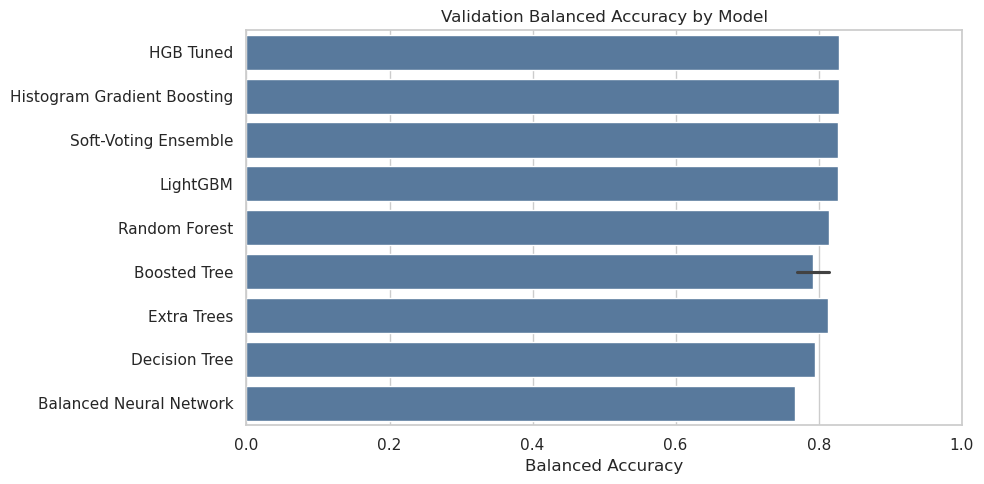

In [18]:
# Compare all validation metrics collected from the model sections above.
comparison_columns = ["Model", "Threshold", "Balanced Accuracy", "Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]
model_comparison = pd.DataFrame(model_results)[comparison_columns].sort_values(
    by="Balanced Accuracy",
    ascending=False,
).reset_index(drop=True)

display(model_comparison.style.format({
    "Threshold": "{:.3f}",
    "Balanced Accuracy": "{:.4f}",
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1 Score": "{:.4f}",
    "ROC AUC": "{:.4f}",
}))

plt.figure(figsize=(10, 5))
sns.barplot(data=model_comparison, x="Balanced Accuracy", y="Model", color="#4C78A8")
plt.title("Validation Balanced Accuracy by Model")
plt.xlim(0, 1)
plt.xlabel("Balanced Accuracy")
plt.ylabel("")
plt.tight_layout()
plt.show()


## Export Submission Files

This final export cell copies every newly created submission CSV so the decision tree, Random Forest, Extra Trees, histogram gradient boosting, boosted tree, and neural-network submissions are all ready to upload.


In [19]:
# Get files from docker container onto local machine for submission
!cp decision_tree_submission.csv .
!cp random_forest_submission.csv .
!cp extra_trees_submission.csv .
!cp hist_gradient_boosting_submission.csv .
!cp hist_gradient_boosting_tuned_submission.csv .
!cp boosted_tree_submission.csv .
!cp lightgbm_submission.csv .
!cp neural_net_submission.csv .
!cp keras_neural_net_submission.csv .
!cp ensemble_submission.csv .

cp: 'decision_tree_submission.csv' and './decision_tree_submission.csv' are the same file
cp: 'random_forest_submission.csv' and './random_forest_submission.csv' are the same file
cp: 'extra_trees_submission.csv' and './extra_trees_submission.csv' are the same file
cp: 'hist_gradient_boosting_submission.csv' and './hist_gradient_boosting_submission.csv' are the same file
cp: 'hist_gradient_boosting_tuned_submission.csv' and './hist_gradient_boosting_tuned_submission.csv' are the same file
cp: 'boosted_tree_submission.csv' and './boosted_tree_submission.csv' are the same file
cp: 'lightgbm_submission.csv' and './lightgbm_submission.csv' are the same file
cp: 'neural_net_submission.csv' and './neural_net_submission.csv' are the same file
cp: cannot stat 'keras_neural_net_submission.csv': No such file or directory
cp: 'ensemble_submission.csv' and './ensemble_submission.csv' are the same file
